## Basic ChatBot With Langgraph(Graph API)

In [14]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [17]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

In [19]:
graph_builder

In [20]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [21]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b")

In [22]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x79681779d640>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x796817575be0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [23]:
#creating chatbot Node function
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [24]:
graph_builder=StateGraph(State)
#adding node
graph_builder.add_node("llmchatbot",chatbot)
#adding edge
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

In [44]:
#compile the graph
graph=graph_builder.compile()

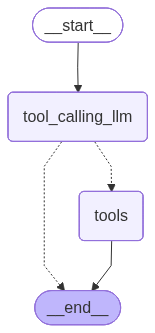

In [39]:
#visualize
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [72]:
responce=graph.invoke({"messages":"explain rest API"})

In [77]:
print(responce["messages"][-1].content)

<think>
Okay, I need to explain REST APIs. Let me start by recalling what I know. REST stands for Representational State Transfer. It's an architectural style for designing networked applications. But wait, maybe I should break that down. So, REST is not a protocol or a standard, but a set of constraints. Right, the key principles include statelessness, client-server architecture, cacheability, and using a uniform interface. Oh, and resources are identified by URLs, and you can perform operations like GET, POST, PUT, DELETE. Those correspond to CRUD operations: Create, Read, Update, Delete.

Wait, I should make sure I'm accurate here. Let me think if there are other constraints. There's also the concept of statelessness, meaning each request from the client to the server must contain all the information needed to understand and process the request. The server shouldn't store any session state. That's important. Also, the uniform interface probably includes things like using standard HT

## CHATBOT with TOOL

In [78]:
import os 
import os
from dotenv import load_dotenv
load_dotenv()

True

In [25]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke("what is tavily?")

{'query': 'what is tavily?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.youtube.com/watch?v=aJs89KXDRxk',
   'title': 'What is Tavily? The Real-Time Web Search Engine ... - YouTube',
   'content': 'Meet Tavily—the AI platform revolutionizing how large language models (LLMs) like ChatGPT get fresh, accurate information from the web in',
   'score': 0.99958915,
   'raw_content': None},
  {'url': 'https://www.linkedin.com/company/tavily',
   'title': 'Tavily - LinkedIn',
   'content': 'Overview:\nWe help agents search, extract, and reason with real-time web data through a single API. Our mission is to onboard the next billion AI agents to the web.\n\nWebsite: https://tavily.com/\nCrunchbase Url: https://www.crunchbase.com/organization/tavily?utm_source=linkedin&utm_medium=referral&utm_campaign=linkedin_companies&utm_content=profile_cta_anon&trk=funding_crunchbase\nLinkedin Url: N/A\n\nIndustry:\nTechnology, Information and Internet\n\nC

In [54]:
def answer(query:str)->int:
    """ 
    answer multiplication of two numbers
    args :
    query : string type

    returns : 
    =int: output int 
    """


In [56]:
tools=[tool,answer]

In [57]:
llm_with_tools=llm.bind_tools(tools)

In [58]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x79681779d640>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x796817575be0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, a

In [59]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [60]:
#node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    )
builder.add_edge("tools",END)

In [61]:
graph=builder.compile()

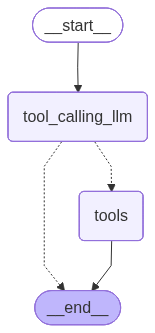

In [40]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [51]:
responce=graph.invoke({"messages":"what are latest AI news"})
for i in responce["messages"]:
    i.pretty_print()

================================ Human Message =================================

whatlatest AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xqmvyvmqt)
 Call ID: xqmvyvmqt
  Args:
    include_images: True
    query: latest AI news
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": ["https://cdn.prod.website-files.com/67166bf779ba8852260f7d1f/694a731a76c9d6876ddf8a8f_latest-ai-news-and-updates.png", "https://vilmate.com/wp-content/uploads/2024/10/latest-updates-o-AI.png.webp", "https://i.ytimg.com/vi/7epeYBjwe64/hq720.jpg?sqp=-oaymwEhCK4FEIIDSFryq4qpAxMIARUAAAAAGAElAADIQj0AgKJD&rs=AOn4CLA_m-CeBPddz9mubF5Ncat8z8lDlA", "https://www.edureka.co/blog/wp-content/uploads/2025/02/Screenshot-2025-02-19-183202-1.png"], "results": [{"url": "https://ww

In [62]:
responce=graph.invoke({"messages":"what is 3 multiplies 47"})
for i in responce["messages"]:
    i.pretty_print()

================================ Human Message =================================

what is 3 multiplies 47
================================== Ai Message ==================================
Tool Calls:
  answer (tdwb3et20)
 Call ID: tdwb3et20
  Args:
    query: 3 multiplies 47
================================= Tool Message =================================
Name: answer

null


## ReAct Agent Architecture

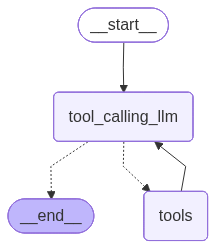

In [63]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    )
builder.add_edge("tools","tool_calling_llm")


graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [64]:
responce=graph.invoke({"messages":"what is the latest AI News and  3 multiplies 47"})
for i in responce["messages"]:
    i.pretty_print()

================================ Human Message =================================

what is the latest AI News and  3 multiplies 47
================================== Ai Message ==================================
Tool Calls:
  tavily_search (m4qthbj4x)
 Call ID: m4qthbj4x
  Args:
    include_images: False
    query: latest AI news
    search_depth: basic
    time_range: day
    topic: general
  answer (5zhwtgzr1)
 Call ID: 5zhwtgzr1
  Args:
    query: 3 * 47
================================= Tool Message =================================
Name: tavily_search

No search results found for 'latest AI news'. Suggestions: Remove time_range argument, Try a more detailed search using 'advanced' search_depth. Try modifying your search parameters with one of these approaches.
================================= Tool Message =================================
Name: answer

null
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jy6rkmxwp)
 Cal

## Adding Memory in Agentic Graph

In [66]:
responce=graph.invoke({"messages":"my name is rukus"})
for i in responce["messages"]:
    i.pretty_print()

================================ Human Message =================================

my name is rukus
================================== Ai Message ==================================

Hello, Rukus! How can I assist you today? If you have any questions or need help with something specific, feel free to ask! 😊


In [67]:
responce=graph.invoke({"messages":"what is my name"})
for i in responce["messages"]:
    i.pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don't have access to your personal information, including your name. If you'd like assistance, please provide your name or clarify your request!


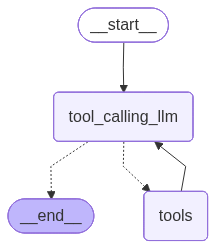

In [79]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
#node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    )
builder.add_edge("tools","tool_calling_llm")


graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:
config={"configurable":{"thread_id":"1"}}
responce_after_adding_memory=graph.invoke({"messages":"my name is rukus"},config=config)
responce

{'messages': [HumanMessage(content='my name is rukus', additional_kwargs={}, response_metadata={}, id='ef840e43-5380-49c1-885e-15fc657ae874'),
  AIMessage(content='Hello, Rukus! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user said, "my name is rukus." Let me think about how to respond. They\'re introducing themselves, so I should acknowledge their name. Maybe say hello and offer assistance. I don\'t need to use any tools here because it\'s just a simple introduction. The functions provided are for searching or answering math problems, but this isn\'t a query that requires a tool. So, just a friendly response to welcome them and ask how I can help.\n'}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 1778, 'total_tokens': 1892, 'completion_time': 0.222143476, 'completion_tokens_details': {'reasoning_tokens': 96}, 'prompt_time': 0.079506242, 'prompt_tokens_details': None, 'queue_time': 0.051819707, 'total_time': 0.301649

In [84]:
responce_after_adding_memory["messages"][-1].content

'Hello, Rukus! How can I assist you today?'

In [87]:
responce_after_adding_memory=graph.invoke({"messages":"what is my name"},config=config)
responce_after_adding_memory["messages"][-1].content

"Your name is Rukus. Let me know if there's anything else I can help with!"

In [88]:
responce_after_adding_memory=graph.invoke({"messages":"do you remember me"},config=config)
responce_after_adding_memory["messages"][-1].content

'Yes, I remember you! Your name is Rukus. How can I assist you today?'